# imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    classification_report, accuracy_score, 
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import mlflow
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

c:\Users\Manindra\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# config

In [2]:
ASSET = "BTC"
INTERVAL = "1h"
VERSION = "v2"

BASELINE_V1_ACCURACY = 0.5260

# Load V2 Data (with OI & Turnover Features)

In [3]:
train_df = pd.read_parquet('../../../data/processed/train_btc_1h_v2.parquet')
test_df  = pd.read_parquet('../../../data/processed/test_btc_1h_v2.parquet')

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Features: {len(train_df.columns) - 2}  (+ target_1h + target_direction)")

Train: (40536, 39)
Test:  (10134, 39)
Features: 37  (+ target_1h + target_direction)


# Separate Targets from Features

In [4]:
y_train = train_df.pop('target_direction')
X_train = train_df.drop(columns=['target_1h'], errors='ignore')

y_test = test_df.pop('target_direction')
X_test = test_df.drop(columns=['target_1h'], errors='ignore')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

new_v2_features = [c for c in X_train.columns if 'oi_' in c or 'turnover_' in c]
print(f"\nNew v2 features ({len(new_v2_features)}): {new_v2_features}")

X_train: (40536, 37), y_train: (40536,)
X_test:  (10134, 37), y_test:  (10134,)

New v2 features (8): ['oi_change_1p', 'oi_change_5p', 'oi_change_20p', 'oi_zscore_50', 'turnover_ratio', 'turnover_change_1p', 'turnover_change_5p', 'turnover_ratio_zscore_50']


# MLflow 

In [5]:
mlflow.set_tracking_uri("http://localhost:5000")
experiment_name = f"{ASSET}_{INTERVAL}_XGBoost_{VERSION}"
mlflow.set_experiment(experiment_name)
mlflow.xgboost.autolog(disable=True)

# GridSearchCV + MLflow Run
# Expanded param grid vs v1 — adds colsample_bytree, reg_alpha, reg_lambda

In [7]:
with mlflow.start_run(run_name=f"XGBoost_{VERSION}_Tuned_GridSearch"):

    mlflow.log_param("asset", ASSET)
    mlflow.log_param("interval", INTERVAL)
    mlflow.log_param("version", VERSION)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))
    mlflow.log_param("baseline_v1_accuracy", BASELINE_V1_ACCURACY)
    
    param_grid = {
        'max_depth':        [3, 5, 7],
        'learning_rate':    [0.01, 0.05, 0.1],
        'n_estimators':     [100, 200, 300],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'reg_alpha':        [0, 0.1],
    }

    base_xgb = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=42
    )

    grid_search = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=1
    )

    grid_search.fit(X_train, y_train)

    print("\n Best Params ")
    print(grid_search.best_params_)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    test_acc  = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred)
    test_rec  = recall_score(y_test, y_pred)
    test_f1   = f1_score(y_test, y_pred)

    print(f"\n Test Metrics ")
    print(f"Accuracy:  {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall:    {test_rec:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")

    delta_vs_v1 = test_acc - BASELINE_V1_ACCURACY
    print(f"\nDelta vs v1 (52.60%): {delta_vs_v1:+.4f} ({delta_vs_v1*100:+.2f}%)")

    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("test_accuracy",  test_acc)
    mlflow.log_metric("test_precision", test_prec)
    mlflow.log_metric("test_recall",    test_rec)
    mlflow.log_metric("test_f1",        test_f1)
    mlflow.log_metric("delta_vs_v1",    delta_vs_v1)

    print("\n Classification Report ")
    print(classification_report(y_test, y_pred, target_names=['DOWN', 'UP']))


Fitting 3 folds for each of 216 candidates, totalling 648 fits

 Best Params 
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0, 'subsample': 0.8}

 Test Metrics 
Accuracy:  0.5261
Precision: 0.5235
Recall:    0.6031
F1 Score:  0.5605

Delta vs v1 (52.60%): +0.0001 (+0.01%)

 Classification Report 
              precision    recall  f1-score   support

        DOWN       0.53      0.45      0.49      5057
          UP       0.52      0.60      0.56      5077

    accuracy                           0.53     10134
   macro avg       0.53      0.53      0.52     10134
weighted avg       0.53      0.53      0.52     10134

🏃 View run XGBoost_v2_Tuned_GridSearch at: http://localhost:5000/#/experiments/17/runs/91e18ad19962429baa38f07883840bfe
🧪 View experiment at: http://localhost:5000/#/experiments/17


# confusion matrix

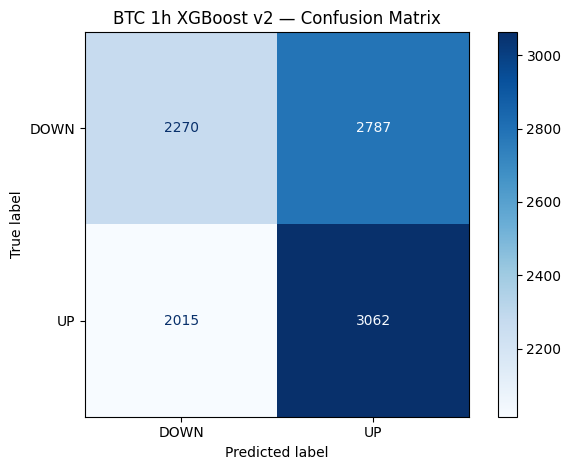

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'{ASSET} {INTERVAL} XGBoost {VERSION} — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'../../../reports/confusion_matrix_{ASSET}_{INTERVAL}_{VERSION}.png', dpi=150)
plt.show()

# features importance

 Top 15 features (v2)
   1. sma_7_dist                     0.1768
   2. returns_5p                     0.0831
   3. ema_12_dist                    0.0519
   4. vwap_dist                      0.0516
   5. close_position                 0.0467
   6. returns_1p                     0.0301
   7. stoch_k                        0.0267
   8. ema_50_dist                    0.0254
   9. returns_20p                    0.0240
  10. returns_10p                    0.0234
  11. sma_30_dist                    0.0233
  12. log_returns                    0.0230
  13. roc_20                         0.0215
  14. macd_sig_pct                   0.0214
  15. hl_ratio                       0.0205


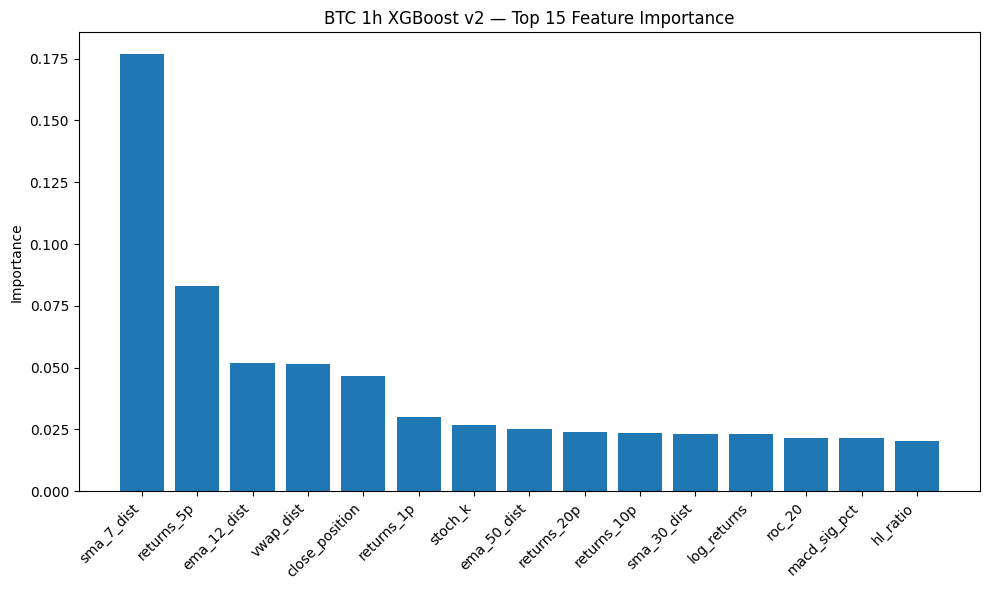

In [9]:
importances = best_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

print(f" Top 15 features ({VERSION})")
for i in range(min(15, len(feature_names))):
    tag = " [NEW]" if feature_names[indices[i]] in new_v2_features else ""
    print(f"  {i+1:2d}. {feature_names[indices[i]]:<30s} {importances[indices[i]]:.4f}{tag}")

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices][:15], align='center', 
        color=['#ff7f0e' if f in new_v2_features else '#1f77b4' for f in feature_names[indices][:15]])
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.title(f'{ASSET} {INTERVAL} XGBoost {VERSION} — Top 15 Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig(f'../../../reports/feature_importance_{ASSET}_{INTERVAL}_{VERSION}.png', dpi=150)
plt.show()

# V1 vs V2 Comparison Summary

In [10]:
print("=" * 55)
print(f"  {ASSET} {INTERVAL} XGBoost — V1 vs V2 Comparison")
print("=" * 55)
print(f"  {'Metric':<25s} {'V1 (29 features)':<18s} {'V2 (37 features)':<18s}")
print("-" * 55)
print(f"  {'Accuracy':<25s} {BASELINE_V1_ACCURACY:<18.4f} {test_acc:<18.4f}")
print(f"  {'Precision':<25s} {'—':<18s} {test_prec:<18.4f}")
print(f"  {'Recall':<25s} {'—':<18s} {test_rec:<18.4f}")
print(f"  {'F1 Score':<25s} {'—':<18s} {test_f1:<18.4f}")
print(f"  {'Features':<25s} {29:<18d} {X_train.shape[1]:<18d}")
print(f"  {'Best max_depth':<25s} {3:<18d} {grid_search.best_params_['max_depth']:<18d}")
print(f"  {'Best lr':<25s} {0.05:<18.2f} {grid_search.best_params_['learning_rate']:<18.2f}")
print("=" * 55)

new_feat_in_top15 = sum(1 for i in indices[:15] if feature_names[i] in new_v2_features)
print(f"\n  New v2 features in Top 15: {new_feat_in_top15}/15")
print(f"  Accuracy change: {delta_vs_v1:+.4f} ({delta_vs_v1*100:+.2f}%)")

  BTC 1h XGBoost — V1 vs V2 Comparison
  Metric                    V1 (29 features)   V2 (37 features)  
-------------------------------------------------------
  Accuracy                  0.5260             0.5261            
  Precision                 —                  0.5235            
  Recall                    —                  0.6031            
  F1 Score                  —                  0.5605            
  Features                  29                 37                
  Best max_depth            3                  3                 
  Best lr                   0.05               0.01              

  New v2 features in Top 15: 0/15
  Accuracy change: +0.0001 (+0.01%)


In [11]:
mlflow.xgboost.autolog(disable=False)

2026/05/17 23:21:28 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 2.0.3. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.
